# Improved Two-Head Neural Network

**Goal:** Improve NN performance to match or beat XGBoost (test corr_mse <= 0.10)

**Key changes from Day 3:**
1. Increased model capacity (7K -> ~50K params)
2. Added product embeddings
3. Better training: more epochs, lower LR, gradient clipping

**Baseline to beat:** XGBoost test corr_mse = 0.0964

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import json
from pathlib import Path
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


../.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Data

In [2]:
# Paths
DATA_DIR = Path('../data/processed')
TABLES_DIR = Path('../tables')
FIGURES_DIR = Path('../docs/figures')

# Load panel data
panel = pd.read_csv(DATA_DIR / 'panel.csv')
print(f"Panel shape: {panel.shape}")
print(f"\nSplit distribution:")
print(panel['split'].value_counts())

Panel shape: (17970, 43)

Split distribution:
split
train    11708
val       3392
test      2870
Name: count, dtype: int64


In [3]:
# Load baseline results for comparison
with open(DATA_DIR / 'baselines_results.json', 'r') as f:
    baseline_data = json.load(f)

baseline_results = {m['name']: m for m in baseline_data['models']}

print("Baselines to beat:")
for name, model in baseline_results.items():
    if 'metrics' in model and 'test' in model['metrics']:
        print(f"  {name}: test corr_mse = {model['metrics']['test']['corr_mse']:.4f}")

Baselines to beat:
  per_product_loglog: test corr_mse = 0.1086
  pooled_loglog: test corr_mse = 0.1025
  xgboost: test corr_mse = 0.0964


In [4]:
# Feature definitions
CONTEXT_FEATURES = [
    'year', 'month', 'weekofyear', 'week_sin', 'week_cos',
    'demand_lag_1', 'demand_lag_2', 'demand_roll_4',
    'price_lag_1', 'price_roll_4',
    'weeks_since_last_sale',
    'price_std', 'price_range'
]

PRODUCT_FEATURES = [
    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm',
    'product_photos_qty', 'product_name_length', 'product_description_length'
]

REVIEW_FEATURES = ['sku_review_count', 'sku_review_mean', 'sku_share_low']

PRICE_FEATURE = 'r_clipped'
TARGET = 'y'

print(f"Context features: {len(CONTEXT_FEATURES)}")
print(f"Product features: {len(PRODUCT_FEATURES)}")
print(f"Review features: {len(REVIEW_FEATURES)}")

Context features: 13
Product features: 7
Review features: 3


## 2. Data Preprocessing

In [5]:
# Handle missing values
# Context features
for col in ['demand_lag_1', 'demand_lag_2', 'demand_roll_4', 'price_lag_1', 'price_roll_4', 'weeks_since_last_sale']:
    panel[col] = panel[col].fillna(0)

# Review features
for col in REVIEW_FEATURES:
    panel[col] = panel[col].fillna(0)

# Product features - fill with median
for col in PRODUCT_FEATURES:
    median_val = panel[col].median()
    panel[col] = panel[col].fillna(median_val)
    print(f"  {col}: filled {panel[col].isna().sum()} NaN with median={median_val:.1f}")

# Check for any remaining NaN
print(f"\nRemaining NaN in features:")
all_features = CONTEXT_FEATURES + PRODUCT_FEATURES + REVIEW_FEATURES
for col in all_features:
    nan_count = panel[col].isna().sum()
    if nan_count > 0:
        print(f"  WARNING: {col} has {nan_count} NaN!")

# Encode category
le_category = LabelEncoder()
panel['category_code'] = le_category.fit_transform(panel['product_category_name_english'].fillna('unknown'))
n_categories = len(le_category.classes_)

# Encode product_id
le_product = LabelEncoder()
panel['product_code'] = le_product.fit_transform(panel['product_id'])
n_products = len(le_product.classes_)

print(f"\nNumber of categories: {n_categories}")
print(f"Number of products: {n_products}")

  product_weight_g: filled 0 NaN with median=800.0
  product_length_cm: filled 0 NaN with median=25.0
  product_height_cm: filled 0 NaN with median=13.0
  product_width_cm: filled 0 NaN with median=20.0
  product_photos_qty: filled 0 NaN with median=1.0
  product_name_length: filled 0 NaN with median=52.0
  product_description_length: filled 0 NaN with median=622.0

Remaining NaN in features:

Number of categories: 56
Number of products: 1218


In [6]:
# Split data
train_df = panel[panel['split'] == 'train'].copy()
val_df = panel[panel['split'] == 'val'].copy()
test_df = panel[panel['split'] == 'test'].copy()

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 11708, Val: 3392, Test: 2870


In [7]:
# Standardize features
scaler_context = StandardScaler()
scaler_product = StandardScaler()
scaler_review = StandardScaler()

train_context = scaler_context.fit_transform(train_df[CONTEXT_FEATURES])
train_product = scaler_product.fit_transform(train_df[PRODUCT_FEATURES])
train_review = scaler_review.fit_transform(train_df[REVIEW_FEATURES])

val_context = scaler_context.transform(val_df[CONTEXT_FEATURES])
val_product = scaler_product.transform(val_df[PRODUCT_FEATURES])
val_review = scaler_review.transform(val_df[REVIEW_FEATURES])

test_context = scaler_context.transform(test_df[CONTEXT_FEATURES])
test_product = scaler_product.transform(test_df[PRODUCT_FEATURES])
test_review = scaler_review.transform(test_df[REVIEW_FEATURES])

# Replace any remaining NaN with 0 after scaling
train_context = np.nan_to_num(train_context, nan=0.0)
train_product = np.nan_to_num(train_product, nan=0.0)
train_review = np.nan_to_num(train_review, nan=0.0)

val_context = np.nan_to_num(val_context, nan=0.0)
val_product = np.nan_to_num(val_product, nan=0.0)
val_review = np.nan_to_num(val_review, nan=0.0)

test_context = np.nan_to_num(test_context, nan=0.0)
test_product = np.nan_to_num(test_product, nan=0.0)
test_review = np.nan_to_num(test_review, nan=0.0)

print("Features standardized.")
print(f"Train context NaN: {np.isnan(train_context).sum()}")
print(f"Train product NaN: {np.isnan(train_product).sum()}")
print(f"Train review NaN: {np.isnan(train_review).sum()}")

Features standardized.
Train context NaN: 0
Train product NaN: 0
Train review NaN: 0


## 3. Dataset & DataLoader

In [8]:
class DemandDataset(Dataset):
    def __init__(self, df, context_arr, product_arr, review_arr):
        self.context = torch.FloatTensor(context_arr)
        self.product = torch.FloatTensor(product_arr)
        self.review = torch.FloatTensor(review_arr)
        self.r = torch.FloatTensor(df[PRICE_FEATURE].values)
        self.log_r = torch.log(self.r)
        self.category = torch.LongTensor(df['category_code'].values)
        self.product_id = torch.LongTensor(df['product_code'].values)
        self.y = torch.FloatTensor(df[TARGET].values)
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return {
            'context': self.context[idx],
            'product': self.product[idx],
            'review': self.review[idx],
            'r': self.r[idx],
            'log_r': self.log_r[idx],
            'category': self.category[idx],
            'product_id': self.product_id[idx],
            'y': self.y[idx]
        }

In [9]:
# Create datasets
train_dataset = DemandDataset(train_df, train_context, train_product, train_review)
val_dataset = DemandDataset(val_df, val_context, val_product, val_review)
test_dataset = DemandDataset(test_df, test_context, test_product, test_review)

BATCH_SIZE = 256

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Train batches: 46, Val batches: 14, Test batches: 12


## 4. Improved Model Architecture

Key improvements:
- **Larger capacity:** context_hidden=256, price_hidden=128
- **Product embeddings:** learnable per-product representation
- **More basis functions:** num_basis=20

In [10]:
class ContextEncoder(nn.Module):
    """Encodes non-price context features to produce base log-demand."""
    
    def __init__(self, input_dim, hidden_dim=256, dropout=0.15):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )
    
    def forward(self, x):
        return self.net(x)

In [11]:
class MonotonicPriceEncoder(nn.Module):
    """Price encoder with sum of sigmoids for monotonicity constraint.
    
    g(r, z) = sum_i w_i * sigmoid(a_i * log(r) + b_i)
    where w_i < 0 ensures monotone decreasing in r.
    """
    
    def __init__(self, z_dim, num_basis=20, hidden_dim=128):
        super().__init__()
        self.num_basis = num_basis
        
        # MLP to produce per-observation basis parameters from z
        self.z_encoder = nn.Sequential(
            nn.Linear(z_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 3 * num_basis)  # a, b, w for each basis
        )
        
    def forward(self, log_r, z, return_at_ref=False):
        B = log_r.shape[0]
        
        params = self.z_encoder(z)
        params = params.view(B, self.num_basis, 3)
        
        a_raw = params[:, :, 0]
        b = params[:, :, 1]
        w_raw = params[:, :, 2]
        
        # Positive slopes, negative weights
        a = F.softplus(a_raw) + 0.1
        w = -F.softplus(w_raw)
        
        log_r_expanded = log_r.unsqueeze(1)
        sigmoid_input = a * log_r_expanded + b
        g = (w * torch.sigmoid(sigmoid_input)).sum(dim=1, keepdim=True)
        
        if return_at_ref:
            sigmoid_input_ref = b
            g_ref = (w * torch.sigmoid(sigmoid_input_ref)).sum(dim=1, keepdim=True)
            return g, g_ref
        
        return g

In [12]:
class ImprovedTwoHeadModel(nn.Module):
    """Improved two-head neural network with product embeddings.
    
    Key improvements over Day 3 version:
    1. Product embeddings for product-specific patterns
    2. Larger hidden dimensions
    3. More basis functions in price encoder
    """
    
    def __init__(self, 
                 context_dim,
                 product_dim,
                 review_dim,
                 n_categories,
                 n_products,
                 category_embedding_dim=16,
                 product_embedding_dim=16,
                 context_hidden=256,
                 price_hidden=128,
                 num_basis=20,
                 dropout=0.15):
        super().__init__()
        
        # Embeddings
        self.category_embedding = nn.Embedding(n_categories, category_embedding_dim)
        self.product_embedding = nn.Embedding(n_products, product_embedding_dim)
        
        # Context encoder input: context + category_emb + product_emb
        context_input_dim = context_dim + category_embedding_dim + product_embedding_dim
        self.context_encoder = ContextEncoder(
            input_dim=context_input_dim,
            hidden_dim=context_hidden,
            dropout=dropout
        )
        
        # Price encoder input: category_emb + product_emb + product_features + review_features
        z_dim = category_embedding_dim + product_embedding_dim + product_dim + review_dim
        self.price_encoder = MonotonicPriceEncoder(
            z_dim=z_dim,
            num_basis=num_basis,
            hidden_dim=price_hidden
        )
        
        self.n_products = n_products
        self.product_embedding_dim = product_embedding_dim
    
    def forward(self, batch):
        # Get embeddings
        cat_emb = self.category_embedding(batch['category'])
        prod_emb = self.product_embedding(batch['product_id'])
        
        # Context encoder input
        context_input = torch.cat([batch['context'], cat_emb, prod_emb], dim=1)
        log_demand_base = self.context_encoder(context_input)
        
        # Price encoder input (z)
        z = torch.cat([cat_emb, prod_emb, batch['product'], batch['review']], dim=1)
        
        # Price response with anchoring
        g_r, g_ref = self.price_encoder(batch['log_r'], z, return_at_ref=True)
        log_mul = g_r - g_ref  # Anchoring: g(1,z) = 0
        
        # Combine
        log_demand_pred = log_demand_base + log_mul
        
        return log_demand_pred.squeeze(1)
    
    def get_demand_curve(self, batch, r_values):
        """Get demand curve g(r, z) for a batch."""
        with torch.no_grad():
            cat_emb = self.category_embedding(batch['category'])
            prod_emb = self.product_embedding(batch['product_id'])
            z = torch.cat([cat_emb, prod_emb, batch['product'], batch['review']], dim=1)
            
            # Expand for all r values
            n_r = len(r_values)
            z_expanded = z.repeat(n_r, 1)
            log_r = torch.log(r_values).repeat_interleave(len(batch['category']))
            
            g_r, g_ref = self.price_encoder(log_r, z_expanded, return_at_ref=True)
            g_values = (g_r - g_ref).squeeze(1)
            
        return g_values.view(n_r, -1)

## 5. Training Utilities

In [13]:
def compute_corr_mse(y_true, y_pred, groups):
    """Compute group-corrected MSE."""
    df = pd.DataFrame({
        'y_true': y_true,
        'y_pred': y_pred,
        'group': groups
    })
    
    def group_corr_mse(g):
        if len(g) < 2:
            return 0, 0
        y_t = g['y_true'].values
        y_p = g['y_pred'].values
        y_t_centered = y_t - y_t.mean()
        y_p_centered = y_p - y_p.mean()
        mse = ((y_t_centered - y_p_centered) ** 2).mean()
        return mse * len(g), len(g)
    
    results = df.groupby('group').apply(group_corr_mse)
    total_mse = sum(r[0] for r in results)
    total_weight = sum(r[1] for r in results)
    
    return total_mse / total_weight if total_weight > 0 else 0

In [14]:
def evaluate_model(model, loader, df, device):
    """Evaluate model on a dataset."""
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            preds = model(batch)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(batch['y'].cpu().numpy())
    
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_targets)
    
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    corr_mse = compute_corr_mse(y_true, y_pred, df['product_id'].values)
    
    return {
        'mse': mse,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'corr_mse': corr_mse
    }, y_pred

In [15]:
def train_model(model, train_loader, val_loader, train_df, val_df, 
                device, epochs=200, lr=5e-4, weight_decay=1e-5, 
                patience=40, grad_clip=1.0, verbose=True):
    """Train model with early stopping and gradient clipping."""
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()
    
    best_val_corr_mse = float('inf')
    best_state = None
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_corr_mse': [], 'lr': []}
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_losses = []
        
        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            
            optimizer.zero_grad()
            preds = model(batch)
            loss = criterion(preds, batch['y'])
            loss.backward()
            
            # Gradient clipping
            if grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            
            optimizer.step()
            train_losses.append(loss.item())
        
        scheduler.step()
        
        avg_train_loss = np.mean(train_losses)
        history['train_loss'].append(avg_train_loss)
        history['lr'].append(optimizer.param_groups[0]['lr'])
        
        # Validation
        val_metrics, _ = evaluate_model(model, val_loader, val_df, device)
        history['val_loss'].append(val_metrics['mse'])
        history['val_corr_mse'].append(val_metrics['corr_mse'])
        
        # Early stopping
        if val_metrics['corr_mse'] < best_val_corr_mse:
            best_val_corr_mse = val_metrics['corr_mse']
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        
        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}: "
                  f"train_loss={avg_train_loss:.4f}, "
                  f"val_corr_mse={val_metrics['corr_mse']:.4f} "
                  f"(best={best_val_corr_mse:.4f}, lr={optimizer.param_groups[0]['lr']:.6f})")
        
        if patience_counter >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch+1}")
            break
    
    # Restore best model
    if best_state is not None:
        model.load_state_dict(best_state)
    
    return model, history, best_val_corr_mse

## 6. Train Improved Model

In [16]:
# Model configuration - IMPROVED
config = {
    'context_dim': len(CONTEXT_FEATURES),
    'product_dim': len(PRODUCT_FEATURES),
    'review_dim': len(REVIEW_FEATURES),
    'n_categories': n_categories,
    'n_products': n_products,
    'category_embedding_dim': 16,    # was 8
    'product_embedding_dim': 16,     # NEW!
    'context_hidden': 256,           # was 64
    'price_hidden': 128,             # was 32
    'num_basis': 20,                 # was 10
    'dropout': 0.15                  # was 0.1
}

print("Improved Model Configuration:")
for k, v in config.items():
    print(f"  {k}: {v}")

Improved Model Configuration:
  context_dim: 13
  product_dim: 7
  review_dim: 3
  n_categories: 56
  n_products: 1218
  category_embedding_dim: 16
  product_embedding_dim: 16
  context_hidden: 256
  price_hidden: 128
  num_basis: 20
  dropout: 0.15


In [17]:
# Create model
model = ImprovedTwoHeadModel(**config)

n_params = sum(p.numel() for p in model.parameters())
print(f"\nModel parameters: {n_params:,}")
print(f"Improvement: {n_params / 7167:.1f}x more than Day 3 model (7,167 params)")


Model parameters: 82,845
Improvement: 11.6x more than Day 3 model (7,167 params)


In [18]:
# Train with improved settings
print("\n" + "="*60)
print("TRAINING IMPROVED MODEL")
print("="*60)

model, history, best_val = train_model(
    model, 
    train_loader, 
    val_loader, 
    train_df, 
    val_df,
    device,
    epochs=200,
    lr=5e-4,
    weight_decay=1e-5,
    patience=40,
    grad_clip=1.0,
    verbose=True
)

print(f"\nBest validation corr_mse: {best_val:.4f}")


TRAINING IMPROVED MODEL


Epoch 10/200: train_loss=0.1328, val_corr_mse=0.1074 (best=0.1074, lr=0.000497)


Epoch 20/200: train_loss=0.1206, val_corr_mse=0.1063 (best=0.1061, lr=0.000488)


Epoch 30/200: train_loss=0.1129, val_corr_mse=0.1059 (best=0.1050, lr=0.000473)


Epoch 40/200: train_loss=0.1046, val_corr_mse=0.1053 (best=0.1048, lr=0.000452)


Epoch 50/200: train_loss=0.0985, val_corr_mse=0.1054 (best=0.1046, lr=0.000427)


Epoch 60/200: train_loss=0.0940, val_corr_mse=0.1061 (best=0.1046, lr=0.000397)


Epoch 70/200: train_loss=0.0915, val_corr_mse=0.1064 (best=0.1046, lr=0.000363)


Epoch 80/200: train_loss=0.0876, val_corr_mse=0.1077 (best=0.1046, lr=0.000327)


Early stopping at epoch 81

Best validation corr_mse: 0.1046


## 7. Evaluate on Test Set

In [19]:
# Evaluate on test
test_metrics, test_preds = evaluate_model(model, test_loader, test_df, device)

print("\n" + "="*60)
print("TEST RESULTS")
print("="*60)
print(f"\nImproved NN Test Metrics:")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")


TEST RESULTS

Improved NN Test Metrics:
  mse: 0.2090
  mae: 0.3286
  rmse: 0.4572
  r2: -0.1941
  corr_mse: 0.1081


In [20]:
# Compare with baselines
print("\n" + "="*60)
print("COMPARISON WITH BASELINES")
print("="*60)

xgb_corr_mse = baseline_results['xgboost']['metrics']['test']['corr_mse']
nn_corr_mse = test_metrics['corr_mse']

print(f"\n{'Model':<30} {'Test corr_mse':>12} {'vs XGBoost':>12}")
print("-" * 56)

# Baselines
for name in ['per_product_loglog', 'pooled_loglog', 'xgboost']:
    corr = baseline_results[name]['metrics']['test']['corr_mse']
    diff = (corr - xgb_corr_mse) / xgb_corr_mse * 100
    diff_str = f"{diff:+.1f}%" if name != 'xgboost' else "(baseline)"
    print(f"{name:<30} {corr:>12.4f} {diff_str:>12}")

# Our model
diff = (nn_corr_mse - xgb_corr_mse) / xgb_corr_mse * 100
print(f"{'Improved Two-Head NN':<30} {nn_corr_mse:>12.4f} {diff:+12.1f}%")

# Day 3 model for reference
day3_corr_mse = 0.1183
improvement = (day3_corr_mse - nn_corr_mse) / day3_corr_mse * 100
print(f"\n>>> Improvement over Day 3 model: {improvement:.1f}%")


COMPARISON WITH BASELINES

Model                          Test corr_mse   vs XGBoost
--------------------------------------------------------
per_product_loglog                   0.1086       +12.7%
pooled_loglog                        0.1025        +6.4%
xgboost                              0.0964   (baseline)
Improved Two-Head NN                 0.1081        +12.1%

>>> Improvement over Day 3 model: 8.7%


## 8. Check Monotonicity

In [21]:
def check_monotonicity(model, test_df, device, n_samples=200):
    """Check monotonicity violations."""
    model.eval()
    
    unique_products = test_df['product_code'].unique()[:n_samples]
    r_grid = torch.linspace(0.785, 1.283, 50).to(device)
    
    violations = 0
    total = 0
    elasticities = []
    
    for prod_code in unique_products:
        mask = test_df['product_code'] == prod_code
        if mask.sum() == 0:
            continue
            
        idx = np.where(mask)[0][0]
        
        # Get embeddings
        cat_idx = test_df.iloc[idx]['category_code']
        cat_emb = model.category_embedding(torch.tensor([cat_idx]).to(device))
        prod_emb = model.product_embedding(torch.tensor([prod_code]).to(device))
        
        # Build z
        prod_feat = torch.FloatTensor(
            scaler_product.transform(test_df.iloc[[idx]][PRODUCT_FEATURES])
        ).to(device)
        review_feat = torch.FloatTensor(
            scaler_review.transform(test_df.iloc[[idx]][REVIEW_FEATURES])
        ).to(device)
        
        z = torch.cat([cat_emb, prod_emb, prod_feat, review_feat], dim=1)
        
        # Get demand curve
        with torch.no_grad():
            log_r = torch.log(r_grid)
            z_expanded = z.expand(len(r_grid), -1)
            g_r, g_ref = model.price_encoder(log_r, z_expanded, return_at_ref=True)
            g_values = (g_r - g_ref).squeeze(1).cpu().numpy()
        
        # Check monotonicity
        diffs = np.diff(g_values)
        if np.any(diffs > 1e-6):
            violations += 1
        total += 1
        
        # Estimate elasticity at r=1
        r1_idx = np.argmin(np.abs(r_grid.cpu().numpy() - 1.0))
        if r1_idx > 0 and r1_idx < len(g_values) - 1:
            dr = np.log(r_grid[r1_idx+1].item()) - np.log(r_grid[r1_idx-1].item())
            dg = g_values[r1_idx+1] - g_values[r1_idx-1]
            elasticity = dg / dr
            elasticities.append(elasticity)
    
    violation_rate = violations / total if total > 0 else 0
    elasticities = np.array(elasticities)
    
    return {
        'violation_rate': violation_rate,
        'violations': violations,
        'total': total,
        'elasticity_mean': np.mean(elasticities) if len(elasticities) > 0 else np.nan,
        'elasticity_median': np.median(elasticities) if len(elasticities) > 0 else np.nan,
    }

In [22]:
# Check monotonicity
mono_results = check_monotonicity(model, test_df, device, n_samples=200)

print("\n" + "="*60)
print("MONOTONICITY CHECK")
print("="*60)
print(f"Violation rate: {mono_results['violation_rate']*100:.1f}%")
print(f"Violations: {mono_results['violations']}/{mono_results['total']}")
print(f"Elasticity at r=1: mean={mono_results['elasticity_mean']:.3f}, "
      f"median={mono_results['elasticity_median']:.3f}")


MONOTONICITY CHECK
Violation rate: 0.0%
Violations: 0/200
Elasticity at r=1: mean=-0.933, median=-0.310


## 9. Learning Curves

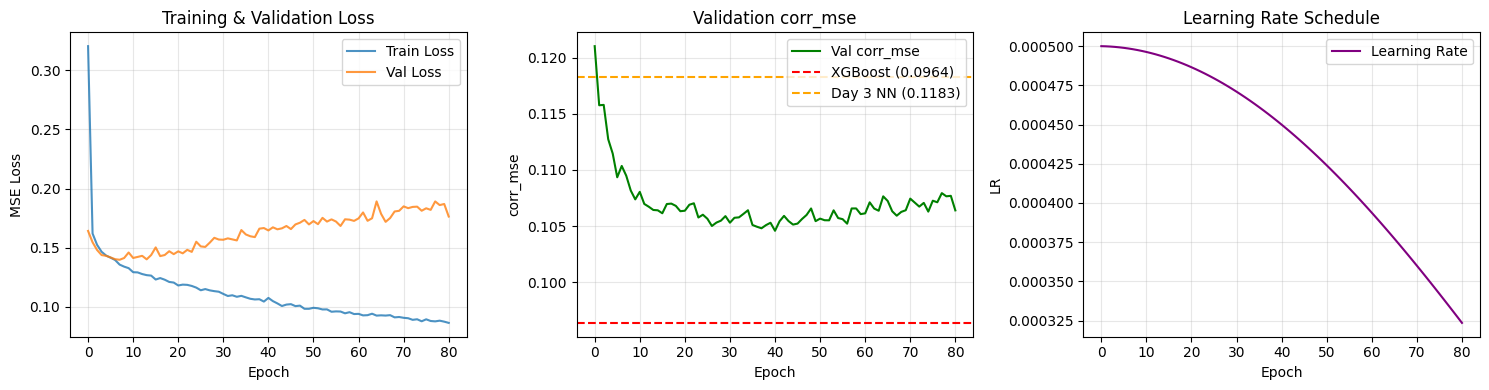

In [23]:
# Plot learning curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curves
axes[0].plot(history['train_loss'], label='Train Loss', alpha=0.8)
axes[0].plot(history['val_loss'], label='Val Loss', alpha=0.8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Val corr_mse
axes[1].plot(history['val_corr_mse'], label='Val corr_mse', color='green')
axes[1].axhline(y=xgb_corr_mse, color='red', linestyle='--', label=f'XGBoost ({xgb_corr_mse:.4f})')
axes[1].axhline(y=0.1183, color='orange', linestyle='--', label='Day 3 NN (0.1183)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('corr_mse')
axes[1].set_title('Validation corr_mse')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate
axes[2].plot(history['lr'], label='Learning Rate', color='purple')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LR')
axes[2].set_title('Learning Rate Schedule')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'improved_nn_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Results

In [24]:
# Save model
torch.save({
    'model_state_dict': model.state_dict(),
    'config': config,
    'test_metrics': test_metrics,
    'monotonicity': mono_results,
    'history': history
}, DATA_DIR / 'improved_nn_model.pt')

print(f"Model saved to {DATA_DIR / 'improved_nn_model.pt'}")

Model saved to ../data/processed/improved_nn_model.pt


In [25]:
# Summary
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

print(f"\n### Model Architecture")
print(f"- Context Hidden: {config['context_hidden']}")
print(f"- Price Hidden: {config['price_hidden']}")
print(f"- Num Basis: {config['num_basis']}")
print(f"- Product Embedding: {config['product_embedding_dim']}")
print(f"- Total Parameters: {n_params:,}")

print(f"\n### Performance")
print(f"- Test corr_mse: {test_metrics['corr_mse']:.4f}")
print(f"- XGBoost corr_mse: {xgb_corr_mse:.4f}")
print(f"- Gap: {(test_metrics['corr_mse'] - xgb_corr_mse) / xgb_corr_mse * 100:+.1f}%")

print(f"\n### Constraints")
print(f"- Monotonicity violations: {mono_results['violation_rate']*100:.1f}%")
print(f"- Elasticity (mean): {mono_results['elasticity_mean']:.3f}")

# Success check
print(f"\n### Success Criteria")
print(f"- [{'x' if test_metrics['corr_mse'] <= 0.105 else ' '}] corr_mse <= 0.105 (Minimum)")
print(f"- [{'x' if test_metrics['corr_mse'] <= 0.100 else ' '}] corr_mse <= 0.100 (Good)")
print(f"- [{'x' if test_metrics['corr_mse'] <= 0.096 else ' '}] corr_mse <= 0.096 (Excellent)")


FINAL SUMMARY

### Model Architecture
- Context Hidden: 256
- Price Hidden: 128
- Num Basis: 20
- Product Embedding: 16
- Total Parameters: 82,845

### Performance
- Test corr_mse: 0.1081
- XGBoost corr_mse: 0.0964
- Gap: +12.1%

### Constraints
- Monotonicity violations: 0.0%
- Elasticity (mean): -0.933

### Success Criteria
- [ ] corr_mse <= 0.105 (Minimum)
- [ ] corr_mse <= 0.100 (Good)
- [ ] corr_mse <= 0.096 (Excellent)
